# Speculative Decoding Acceptance Pattern Analysis

Reproduces and extends the analysis from **Section 3.2** of *"Fail Fast, Win Big"* (Pan et al., 2025).

We use vLLM's built-in scheduler instrumentation (`VLLM_SPEC_DECODE_TRACE_FILE`) to capture
**ground-truth** per-token accept/reject decisions during speculative decoding, then analyze:

1. **Acceptance raster patterns** across representative datasets
2. **Entropy distribution** at easy vs. hard regions
3. **KL divergence** between target and draft model
4. **Effect of `spec_length`** on acceptance patterns

**Models:** Qwen3.5-9B (target) + Qwen3.5-0.8B (separate draft model, `method='draft_model'`)

**Note:** vLLM's default behaviour auto-promotes Qwen3.5 to MTP, so we patch the config
to respect the explicit `method='draft_model'` setting.

## 1. Setup & Configuration

In [24]:
import gc
import json
import os
import tempfile
import time
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# ── Model paths ──────────────────────────────────────────────────────────
# Adjust these to your local cache or HuggingFace IDs
TARGET_MODEL = "Qwen/Qwen3-8B"
DRAFT_MODEL  = "Qwen/Qwen3-0.6B"
DTYPE = "float16"
MAX_MODEL_LEN = 4096
GPU_MEM_UTIL = 0.90
TRACE_LOGPROBS_K = 20  # top-K logprobs captured per token

# ── Plot style ────────────────────────────────────────────────────────────
ACCEPT_COLOR = (0/255, 100/255, 60/255)   # dark green (paper style)
REJECT_COLOR = (1.0, 1.0, 1.0)            # white

print(f"Target: {TARGET_MODEL}")
print(f"Draft:  {DRAFT_MODEL}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Target: Qwen/Qwen3-8B
Draft:  Qwen/Qwen3-0.6B
CUDA available: True
GPU: Tesla V100-SXM2-32GB


## 2. Dataset Loading

We select **4 representative datasets** commonly used in speculative decoding research:

| Dataset | Domain | Expected Pattern |
|---------|--------|------------------|
| **GSM8K** | Math reasoning | Formulaic steps (easy) + novel reasoning (hard) |
| **HumanEval** | Code generation | Boilerplate (easy) + logic (hard) |
| **CNN/DailyMail** | Summarization | Copying/paraphrasing (easy) + abstraction (hard) |
| **MT-Bench** | Open-ended instruction | Mixed — creative vs. structured responses |

In [25]:
from datasets import load_dataset

MAX_NEW_TOKENS = 400
CNNDM_CAP = 500   # CNN/DailyMail is 11k — cap at 500 representative samples
BATCH_SIZE = 50   # generate in batches to bound peak KV-cache usage

# ── GSM8K: math word problems (1319 test samples) ─────────────────────────
gsm8k = load_dataset("openai/gsm8k", "main", split="test")
gsm8k_prompts = [
    f"Solve this math problem step by step:\n{row['question']}"
    for row in gsm8k
]

# ── HumanEval: code generation (164 test samples) ────────────────────────
humaneval = load_dataset("openai/openai_humaneval", split="test")
humaneval_prompts = [
    f"Complete the following Python function:\n{row['prompt']}"
    for row in humaneval
]

# ── CNN/DailyMail: summarization — capped for memory ────────────────────
cnndm = load_dataset("abisee/cnn_dailymail", "3.0.0", split="test")
cnndm_prompts = [
    f"Summarize the following article in detail:\n{row['article'][:1500]}"
    for row in cnndm.select(range(CNNDM_CAP))
]

# ── MT-Bench: open-ended instruction (80 questions) ──────────────────────
mtbench = load_dataset("HuggingFaceH4/mt_bench_prompts", split="train")
mtbench_prompts = [
    row["prompt"][0] if isinstance(row["prompt"], list) else row["prompt"]
    for row in mtbench
]

ALL_DATASETS = {
    "GSM8K (Math)":          gsm8k_prompts,
    "HumanEval (Code)":      humaneval_prompts,
    "CNN/DailyMail (Summary)": cnndm_prompts,
    "MT-Bench (Open-ended)": mtbench_prompts,
}

for name, prompts in ALL_DATASETS.items():
    print(f"{name}: {len(prompts)} prompts")
    print(f"  Example: {prompts[0][:100]}...\n")


GSM8K (Math): 1319 prompts
  Example: Solve this math problem step by step:
Janet’s ducks lay 16 eggs per day. She eats three for breakfas...

HumanEval (Code): 164 prompts
  Example: Complete the following Python function:
from typing import List


def has_close_elements(numbers: Li...

CNN/DailyMail (Summary): 500 prompts
  Example: Summarize the following article in detail:
(CNN)The Palestinian Authority officially became the 123r...

MT-Bench (Open-ended): 80 prompts
  Example: Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experience...



## 3. Helper Functions

In [26]:
def generate_with_tracing(
    prompts: list[str],
    spec_len: int = 4,
    max_new_tokens: int = 400,
    target_model: str = TARGET_MODEL,
    draft_model: str = DRAFT_MODEL,
) -> dict:
    """
    Run vLLM with a separate draft model and scheduler-level tracing.
    Uses method='draft_model' to force independent draft model (not MTP).
    Returns acceptance masks, target logprobs, and draft logprobs — all
    captured in-flight from the scheduler trace (no re-scoring pass needed).
    """
    from vllm import LLM, SamplingParams

    trace_fd, trace_file = tempfile.mkstemp(prefix="spec_trace_", suffix=".jsonl")
    os.close(trace_fd)
    os.environ["VLLM_SPEC_DECODE_TRACE_FILE"] = trace_file

    speculative_config = {
        "model": draft_model,
        "method": "draft_model",
        "num_speculative_tokens": spec_len,
    }

    llm = LLM(
        model=target_model,
        trust_remote_code=True,
        speculative_config=speculative_config,
        disable_log_stats=False,
        dtype=DTYPE,
        max_model_len=MAX_MODEL_LEN,
        gpu_memory_utilization=GPU_MEM_UTIL,
        enforce_eager=True,
    )

    sampling_params = SamplingParams(
        temperature=0.0,
        max_tokens=max_new_tokens,
        logprobs=TRACE_LOGPROBS_K,  # target logprobs captured in-flight by scheduler
    )

    t0 = time.time()
    # Generate in batches to bound peak KV-cache and CPU-RAM usage
    all_outputs = []
    for batch_start in range(0, len(prompts), BATCH_SIZE):
        batch = prompts[batch_start: batch_start + BATCH_SIZE]
        all_outputs.extend(llm.generate(batch, sampling_params))
    elapsed = time.time() - t0

    output_token_ids = []
    request_ids = []
    for out in all_outputs:
        output_token_ids.append(list(out.outputs[0].token_ids))
        request_ids.append(out.request_id)

    # Collect metrics
    metrics = {}
    try:
        for m in llm.get_metrics():
            if "spec_decode" in m.name:
                metrics[m.name] = m.values if hasattr(m, "values") else m.value
    except Exception:
        pass

    del os.environ["VLLM_SPEC_DECODE_TRACE_FILE"]
    del llm
    gc.collect()
    torch.cuda.empty_cache()

    # Load full trace: acceptance + target_logprobs + draft_logprobs per request
    raw_trace: dict[str, dict] = {}
    with open(trace_file) as f:
        for line in f:
            line = line.strip()
            if line:
                e = json.loads(line)
                raw_trace[e["request_id"]] = e
    try:
        os.unlink(trace_file)
    except OSError:
        pass

    # Match trace entries, extract logprobs and acceptance masks
    all_acceptance = []
    target_logprobs_by_seq = []
    draft_logprobs_by_seq = []
    for req_id, o_ids in zip(request_ids, output_token_ids):
        entry = None
        for trace_id, v in raw_trace.items():
            if trace_id.startswith(req_id + "-") or trace_id == req_id:
                entry = v
                break
        entry = entry or {}

        mask = entry.get("acceptance", [True] * len(o_ids))
        mask = mask[:len(o_ids)]
        while len(mask) < len(o_ids):
            mask.append(True)
        all_acceptance.append(mask)

        n = len(o_ids)
        target_logprobs_by_seq.append(
            (entry.get("target_logprobs") or [{}] * n)[:n]
        )
        draft_logprobs_by_seq.append(
            (entry.get("draft_logprobs") or [None] * n)[:n]
        )
        # Free entry immediately — don't accumulate all trace data in RAM
        entry = None

    total_tokens = sum(len(o) for o in output_token_ids)
    return {
        "output_token_ids": output_token_ids,
        "request_ids": request_ids,
        "acceptance": all_acceptance,
        "target_logprobs": target_logprobs_by_seq,
        "draft_logprobs": draft_logprobs_by_seq,
        "metrics": metrics,
        "elapsed": elapsed,
        "total_tokens": total_tokens,
        "tok_per_sec": total_tokens / elapsed if elapsed > 0 else 0,
    }


In [43]:
def compute_entropy_from_logprobs(pos_logprobs) -> float:
    """
    Compute entropy from a logprobs dict.
    Accepts {token_id: float} (from trace) or {token_id: Logprob} (vLLM object).
    """
    if not pos_logprobs:
        return float('nan')
    vals = list(pos_logprobs.values())
    log_probs = [v if isinstance(v, (int, float)) else v.logprob for v in vals]
    probs = np.exp(log_probs)
    probs = probs / probs.sum()
    return float(-np.sum(probs * np.log(probs + 1e-12)))


def compute_kl_from_logprobs(target_lp, draft_lp,
                              log_eps: float = -20.0) -> float:
    """
    Compute KL(target || draft) using target's top-K as support.
    For draft tokens absent from top-K, assign exp(log_eps) probability.
    This avoids NaN at rejected positions where distributions barely overlap.
    """
    if not target_lp or not draft_lp:
        return float('nan')

    def _lp(v):
        return v if isinstance(v, (int, float)) else v.logprob

    target_tokens = list(target_lp.keys())
    p = np.array([_lp(target_lp[t]) for t in target_tokens], dtype=np.float64)
    q = np.array([
        _lp(draft_lp[t]) if t in draft_lp else log_eps
        for t in target_tokens
    ], dtype=np.float64)
    # Renormalise over the target's support (consistent top-K approximation)
    p = np.exp(p - p.max()); p /= p.sum()
    q = np.exp(q - q.max()); q /= q.sum()
    return float(max(0.0, np.sum(p * np.log((p + 1e-12) / (q + 1e-12)))))


In [28]:
def plot_raster(
    acceptance_list: list[list[bool]],
    labels: list[str],
    title: str = "",
    ax=None,
):
    """Plot acceptance raster (green=accepted, white=rejected)."""
    max_len = max(len(a) for a in acceptance_list)
    n = len(acceptance_list)
    img = np.ones((n, max_len, 3), dtype=np.float32)
    for row, accepted in enumerate(acceptance_list):
        for col, acc in enumerate(accepted):
            if acc:
                img[row, col] = ACCEPT_COLOR

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 0.7 * n + 1.5))
    ax.imshow(img, aspect="auto", interpolation="nearest")
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Output Token Index", fontsize=10)
    ax.set_title(title, fontsize=11, style="italic")

    green_patch = mpatches.Patch(color=ACCEPT_COLOR, label='accepted (easy)')
    white_patch = mpatches.Patch(facecolor="white", edgecolor="gray",
                                  label='rejected (hard)')
    ax.legend(handles=[green_patch, white_patch],
              loc="lower right", fontsize=8, framealpha=0.8)
    return ax

## 4. Experiment 1: Acceptance Patterns Across Datasets

Generate with `spec_len=4` across all four datasets and visualize the raster patterns.

In [29]:
SPEC_LEN = 4

results = {}
for ds_name, prompts in ALL_DATASETS.items():
    print(f"\n{'='*60}")
    print(f"Generating: {ds_name} ({len(prompts)} prompts, spec_len={SPEC_LEN})")
    print(f"{'='*60}")

    result = generate_with_tracing(
        prompts=prompts,
        spec_len=SPEC_LEN,
        max_new_tokens=MAX_NEW_TOKENS,
    )

    results[ds_name] = result

    total = sum(len(a) for a in result["acceptance"])
    agreed = sum(sum(a) for a in result["acceptance"])
    print(f"  Overall: {agreed}/{total} = {agreed/total:.2%}")
    print(f"  Throughput: {result['tok_per_sec']:.1f} tok/s")



Generating: GSM8K (Math) (1319 prompts, spec_len=4)
INFO 04-12 21:12:48 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'float16', 'max_model_len': 4096, 'enforce_eager': True, 'speculative_config': {'model': 'Qwen/Qwen3-0.6B', 'method': 'draft_model', 'num_speculative_tokens': 4}, 'model': 'Qwen/Qwen3-8B'}
WARNING 04-12 21:12:48 [envs.py:1752] Unknown vLLM environment variable detected: VLLM_SPEC_DECODE_TRACE_FILE
INFO 04-12 21:12:51 [model.py:549] Resolved architecture: Qwen3ForCausalLM
WARNING 04-12 21:12:51 [model.py:2017] Casting torch.bfloat16 to torch.float16.
INFO 04-12 21:12:51 [model.py:1679] Using max model len 4096
INFO 04-12 21:12:53 [model.py:549] Resolved architecture: Qwen3ForCausalLM
WARNING 04-12 21:12:53 [model.py:2017] Casting torch.bfloat16 to torch.float16.
INFO 04-12 21:12:53 [model.py:1679] Using max model len 40960
WARNING 04-12 21:12:53 [vllm.py:847] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting

Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]


(EngineCore pid=825382) INFO 04-12 21:13:14 [weight_utils.py:827] Prefetching checkpoint files: 10% (1/5)
(EngineCore pid=825382) INFO 04-12 21:13:14 [weight_utils.py:827] Prefetching checkpoint files: 20% (2/5)
(EngineCore pid=825382) INFO 04-12 21:13:14 [weight_utils.py:827] Prefetching checkpoint files: 30% (3/5)
(EngineCore pid=825382) INFO 04-12 21:13:14 [weight_utils.py:827] Prefetching checkpoint files: 40% (4/5)
(EngineCore pid=825382) INFO 04-12 21:13:15 [weight_utils.py:827] Prefetching checkpoint files: 50% (5/5)
(EngineCore pid=825382) INFO 04-12 21:13:15 [weight_utils.py:845] Prefetching checkpoint files into page cache finished in 1.27s


Loading safetensors checkpoint shards:  20% Completed | 1/5 [00:02<00:09,  2.28s/it]
Loading safetensors checkpoint shards:  40% Completed | 2/5 [00:04<00:06,  2.04s/it]
Loading safetensors checkpoint shards:  60% Completed | 3/5 [00:06<00:03,  1.99s/it]
Loading safetensors checkpoint shards:  80% Completed | 4/5 [00:07<00:01,  1.82s/it]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:08<00:00,  1.39s/it]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:08<00:00,  1.65s/it]
(EngineCore pid=825382) 
(EngineCore pid=825382) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=825382) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=825382) INFO 04-12 21:13:22 [default_loader.py:384] Loading weights took 8.30 seconds
(EngineCore pid=825382) INFO 04-12 21:13:22 [gpu_model_runner.py:4783] Loading drafter model...
(EngineCore pid=825382) INFO 04-12 21:13:22 [vllm.py:789] Asynchronous scheduling is disabled.
(EngineCore pid=825382) WARNING 04-12 21:13:22 [vllm.py:847] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
(EngineCore pid=825382) WARNING 04-12 21:13:22 [vllm.py:858] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
(EngineCore pid=825382) WARNING 04-12 21:13:22 [vllm.py:1340] max_num_scheduled_tokens is set to 7936 based on the speculative decoding settings. This may lead to suboptimal performance. Consider increasing max_num_batched_tokens to accommodate the additional draft token slots, or decrease num_speculative_tokens or 

...

INFO 04-12 21:37:35 [loggers.py:259] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 519.4 tokens/s, Running: 27 reqs, Waiting: 0 reqs, GPU KV cache usage: 25.1%, Prefix cache hit rate: 0.0%
INFO 04-12 21:37:35 [metrics.py:101] SpecDecoding metrics: Mean acceptance length: 3.13, Accepted throughput: 354.26 tokens/s, Drafted throughput: 664.22 tokens/s, Accepted: 3599 tokens, Drafted: 6748 tokens, Per-position acceptance rate: 0.734, 0.564, 0.455, 0.381, Avg Draft acceptance rate: 53.3%


Processed prompts:  90%|█████████ | 27/30 [00:28<00:00,  3.05it/s, est. speed input: 103.88 toks/s, output: 383.74 toks/s]

INFO 04-12 21:37:45 [loggers.py:259] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 285.2 tokens/s, Running: 1 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.9%, Prefix cache hit rate: 0.0%
INFO 04-12 21:37:45 [metrics.py:101] SpecDecoding metrics: Mean acceptance length: 2.95, Accepted throughput: 190.93 tokens/s, Drafted throughput: 392.37 tokens/s, Accepted: 1925 tokens, Drafted: 3956 tokens, Per-position acceptance rate: 0.723, 0.520, 0.388, 0.315, Avg Draft acceptance rate: 48.7%


Processed prompts: 100%|██████████| 30/30 [00:29<00:00,  1.02it/s, est. speed input: 100.83 toks/s, output: 405.60 toks/s]
[rank0]:[W412 21:37:47.793850486 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


(EngineCore pid=830577) INFO 04-12 21:37:46 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=830577) INFO 04-12 21:37:46 [core.py:1233] Shutdown complete
  Overall: 25771/31979 = 80.59%
  Throughput: 499.1 tok/s


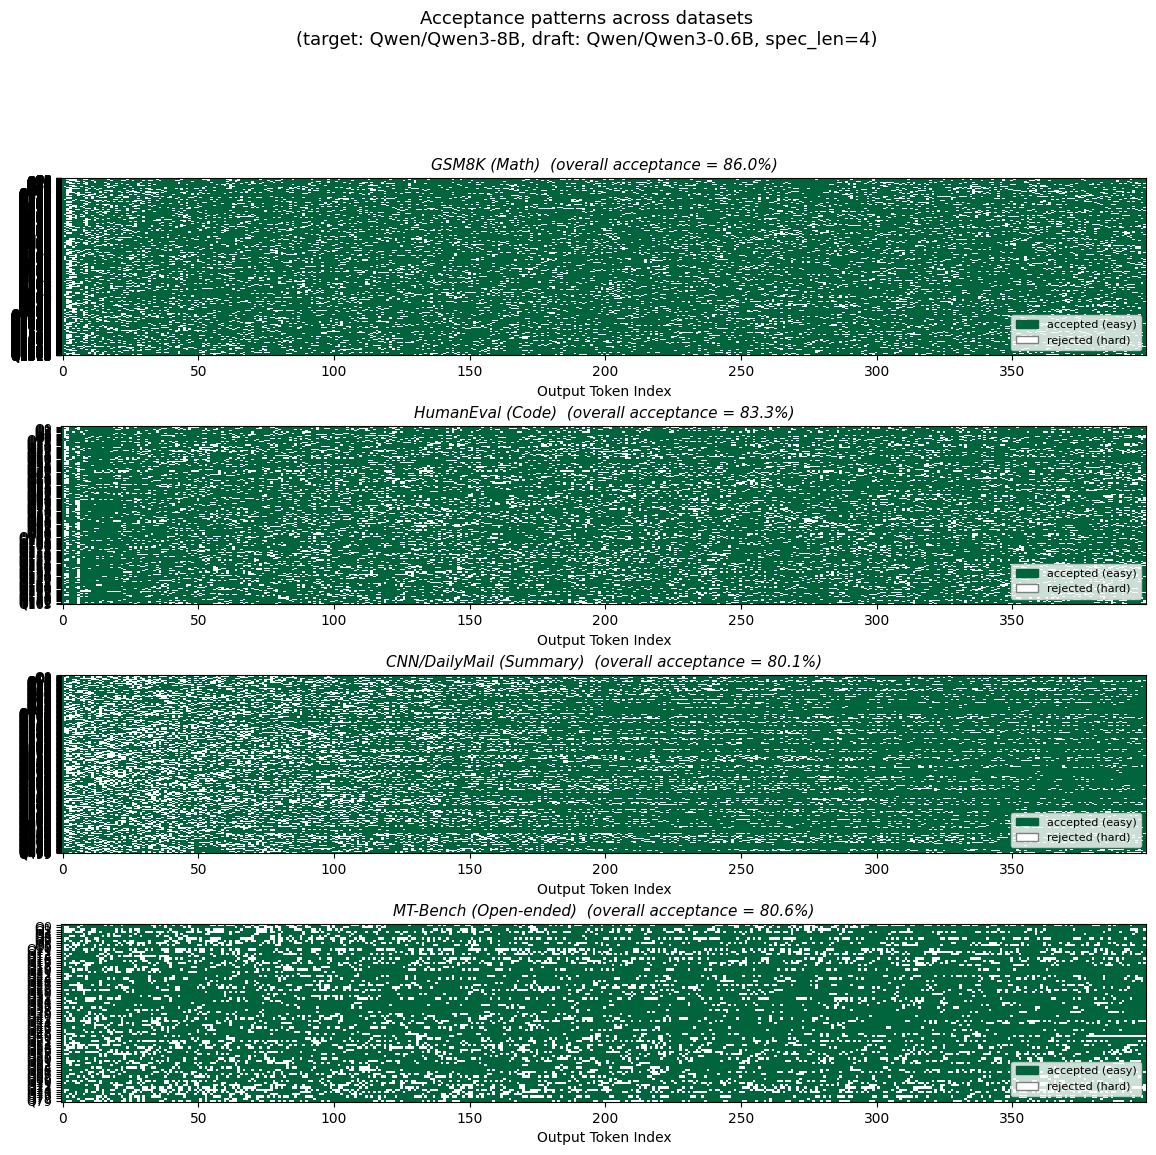

Saved: raster_all_datasets.png


In [30]:
# ── Raster plot per dataset ───────────────────────────────────────────────
fig, axes = plt.subplots(len(ALL_DATASETS), 1,
                         figsize=(14, 3 * len(ALL_DATASETS)),
                         gridspec_kw={"hspace": 0.4})

for ax, (ds_name, result) in zip(axes, results.items()):
    labels = [f"Q{i}" for i in range(len(result["acceptance"]))]
    total = sum(len(a) for a in result["acceptance"])
    agreed = sum(sum(a) for a in result["acceptance"])
    rate = agreed / total if total else 0
    plot_raster(
        result["acceptance"], labels,
        title=f"{ds_name}  (overall acceptance = {rate:.1%})",
        ax=ax,
    )

fig.suptitle(
    f"Acceptance patterns across datasets\n"
    f"(target: {TARGET_MODEL}, draft: {DRAFT_MODEL}, spec_len={SPEC_LEN})",
    fontsize=13, y=1.02,
)
plt.savefig("raster_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: raster_all_datasets.png")

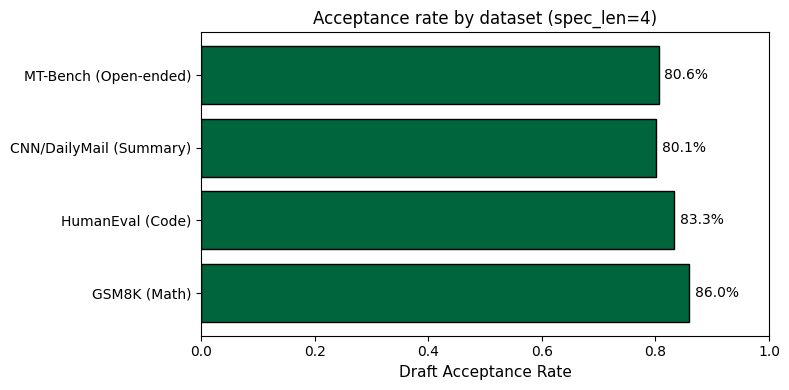

In [31]:
# ── Summary bar chart ─────────────────────────────────────────────────────
ds_names = list(results.keys())
ds_rates = []
for ds_name in ds_names:
    acc = results[ds_name]["acceptance"]
    total = sum(len(a) for a in acc)
    agreed = sum(sum(a) for a in acc)
    ds_rates.append(agreed / total if total else 0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ds_names, ds_rates, color=ACCEPT_COLOR, edgecolor="black")
ax.set_xlim(0, 1)
ax.set_xlabel("Draft Acceptance Rate", fontsize=11)
ax.set_title("Acceptance rate by dataset (spec_len=4)", fontsize=12)
for bar, rate in zip(bars, ds_rates):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{rate:.1%}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("acceptance_rate_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Experiment 2: Entropy Distribution at Easy vs. Hard Regions

Target model entropy per output token, read directly from the scheduler trace
(captured in-flight — no separate re-scoring pass needed).

- **Easy** (accepted) positions → low entropy
- **Hard** (rejected) positions → high entropy


In [32]:
# ── Load target logprobs (extracted from trace inside generate_with_tracing) ──
target_logprobs = {
    ds_name: results[ds_name]["target_logprobs"]
    for ds_name in ALL_DATASETS
}

for ds_name in ALL_DATASETS:
    n_with = sum(1 for seq in target_logprobs[ds_name]
                 for p in seq if p and len(p) > 0)
    n_total = sum(len(seq) for seq in target_logprobs[ds_name])
    print(f"{ds_name}: {n_with}/{n_total} positions have target logprobs")


GSM8K (Math): 529837/529837 positions have target logprobs
HumanEval (Code): 65879/65879 positions have target logprobs
CNN/DailyMail (Summary): 200882/200882 positions have target logprobs
MT-Bench (Open-ended): 32113/32113 positions have target logprobs


In [33]:
# ── Compute entropy at each position ──────────────────────────────────────
entropy_data = {}  # {ds_name: {"easy": [...], "hard": [...]}}

for ds_name in ALL_DATASETS:
    easy_entropies = []
    hard_entropies = []
    for acc_mask, seq_logprobs in zip(
        results[ds_name]["acceptance"],
        target_logprobs[ds_name],
    ):
        for accepted, pos_lp in zip(acc_mask, seq_logprobs):
            h = compute_entropy_from_logprobs(pos_lp)
            if not np.isnan(h):
                if accepted:
                    easy_entropies.append(h)
                else:
                    hard_entropies.append(h)
    entropy_data[ds_name] = {"easy": easy_entropies, "hard": hard_entropies}
    print(f"{ds_name}: easy={np.mean(easy_entropies):.3f} "
          f"(n={len(easy_entropies)}), "
          f"hard={np.mean(hard_entropies):.3f} "
          f"(n={len(hard_entropies)})")

GSM8K (Math): easy=0.160 (n=453752), hard=0.680 (n=73848)
HumanEval (Code): easy=0.143 (n=54650), hard=0.555 (n=10950)
CNN/DailyMail (Summary): easy=0.426 (n=160281), hard=1.429 (n=39719)
MT-Bench (Open-ended): easy=0.228 (n=25771), hard=0.877 (n=6208)


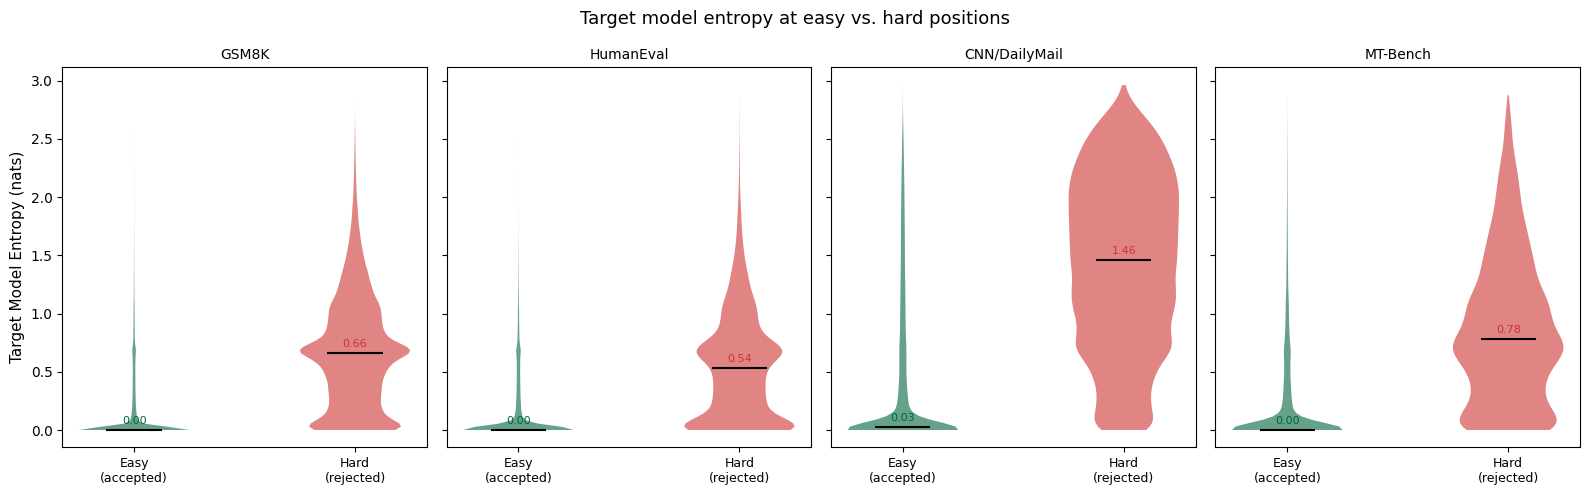

In [34]:
# ── Entropy distribution: violin plots ───────────────────────────────────
fig, axes = plt.subplots(1, len(ALL_DATASETS), figsize=(16, 5), sharey=True)

for ax, ds_name in zip(axes, ALL_DATASETS):
    easy = entropy_data[ds_name]["easy"]
    hard = entropy_data[ds_name]["hard"]
    if not easy or not hard:
        ax.set_title(f"{ds_name.split(' (')[0]}\n(no data)", fontsize=10)
        continue

    parts = ax.violinplot(
        [easy, hard], positions=[0, 1], showmedians=True, showextrema=False
    )
    for idx_pc, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(ACCEPT_COLOR if idx_pc == 0 else "#cc3333")
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Easy\n(accepted)", "Hard\n(rejected)"], fontsize=9)
    ax.set_title(ds_name.split(" (")[0], fontsize=10)
    ax.text(0, np.median(easy) + 0.05, f"{np.median(easy):.2f}",
            ha="center", fontsize=8, color=ACCEPT_COLOR)
    ax.text(1, np.median(hard) + 0.05, f"{np.median(hard):.2f}",
            ha="center", fontsize=8, color="#cc3333")

axes[0].set_ylabel("Target Model Entropy (nats)", fontsize=11)
fig.suptitle("Target model entropy at easy vs. hard positions", fontsize=13)
plt.tight_layout()
plt.savefig("entropy_easy_vs_hard.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Experiment 3: KL Divergence Between Target and Draft

Draft model logprobs are captured in-flight in the scheduler trace at accepted
token positions - no separate re-scoring pass needed.

KL divergence is computed as $D_{\\mathrm{KL}}(p_{\\text{target}} \\| p_{\\text{draft}})$
using the top-K logprobs captured for both models.


In [40]:
# ── Load draft logprobs (extracted from trace inside generate_with_tracing) ──
draft_logprobs = {
    ds_name: results[ds_name]["draft_logprobs"]
    for ds_name in ALL_DATASETS
}

for ds_name in ALL_DATASETS:
    n_with = sum(1 for seq in draft_logprobs[ds_name]
                 for p in seq if p is not None and len(p) > 0)
    n_total = sum(len(seq) for seq in draft_logprobs[ds_name])
    print(f"{ds_name}: {n_with}/{n_total} positions have draft logprobs")


GSM8K (Math): 455041/529837 positions have draft logprobs
HumanEval (Code): 57260/65879 positions have draft logprobs
CNN/DailyMail (Summary): 176115/200882 positions have draft logprobs
MT-Bench (Open-ended): 28164/32113 positions have draft logprobs


In [44]:
# ── Compute KL at each position ──────────────────────────────────────────
kl_data = {}  # {ds_name: {"easy": [...], "hard": [...]}}

for ds_name in ALL_DATASETS:
    easy_kl = []
    hard_kl = []
    for acc_mask, t_lps, d_lps in zip(
        results[ds_name]["acceptance"],
        target_logprobs[ds_name],
        draft_logprobs[ds_name],
    ):
        for accepted, t_lp, d_lp in zip(acc_mask, t_lps, d_lps):
            kl = compute_kl_from_logprobs(t_lp, d_lp)
            if not np.isnan(kl):
                if accepted:
                    easy_kl.append(kl)
                else:
                    hard_kl.append(kl)
    kl_data[ds_name] = {"easy": easy_kl, "hard": hard_kl}
    print(f"{ds_name}: KL_easy={np.mean(easy_kl) if easy_kl else float('nan'):.4f} "
          f"(n={len(easy_kl)}), "
          f"KL_hard={np.mean(hard_kl) if hard_kl else float('nan'):.4f} "
          f"(n={len(hard_kl)})")


GSM8K (Math): KL_easy=7.1409 (n=379733), KL_hard=8.4738 (n=73848)
HumanEval (Code): KL_easy=7.1111 (n=46122), KL_hard=8.9784 (n=10950)
CNN/DailyMail (Summary): KL_easy=7.5677 (n=135849), KL_hard=7.8192 (n=39719)
MT-Bench (Open-ended): KL_easy=7.1614 (n=21868), KL_hard=7.9911 (n=6208)


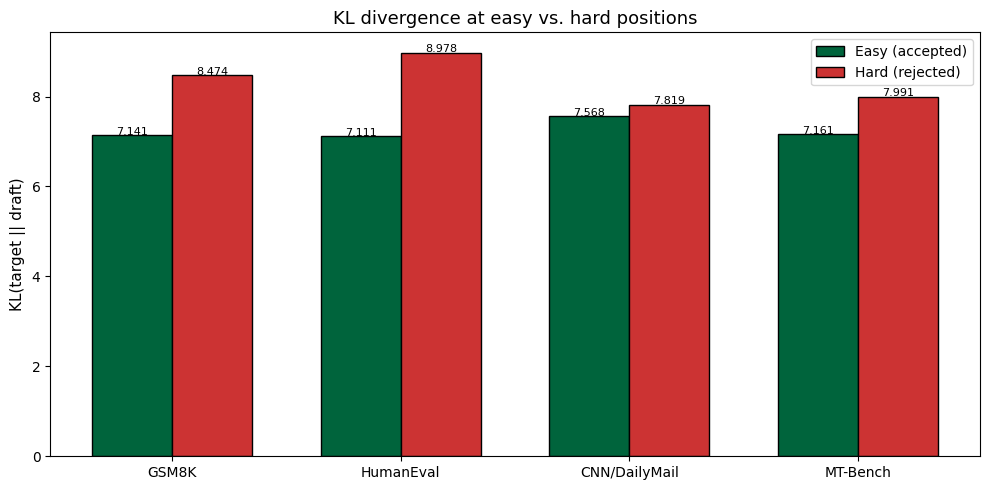

In [45]:
# ── KL divergence: bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ds_names_short = [n.split(" (")[0] for n in ALL_DATASETS]
x = np.arange(len(ds_names_short))
width = 0.35

easy_means = [np.mean(kl_data[ds]["easy"]) for ds in ALL_DATASETS]
hard_means = [np.mean(kl_data[ds]["hard"]) for ds in ALL_DATASETS]

bars1 = ax.bar(x - width/2, easy_means, width, label="Easy (accepted)",
               color=ACCEPT_COLOR, edgecolor="black")
bars2 = ax.bar(x + width/2, hard_means, width, label="Hard (rejected)",
               color="#cc3333", edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(ds_names_short, fontsize=10)
ax.set_ylabel("KL(target || draft)", fontsize=11)
ax.set_title("KL divergence at easy vs. hard positions", fontsize=13)
ax.legend(fontsize=10)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("kl_easy_vs_hard.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_786392/3678109241.py:21: RuntimeWarning: Mean of empty slice
  mean_kl = np.nanmean(kl_matrix, axis=0)


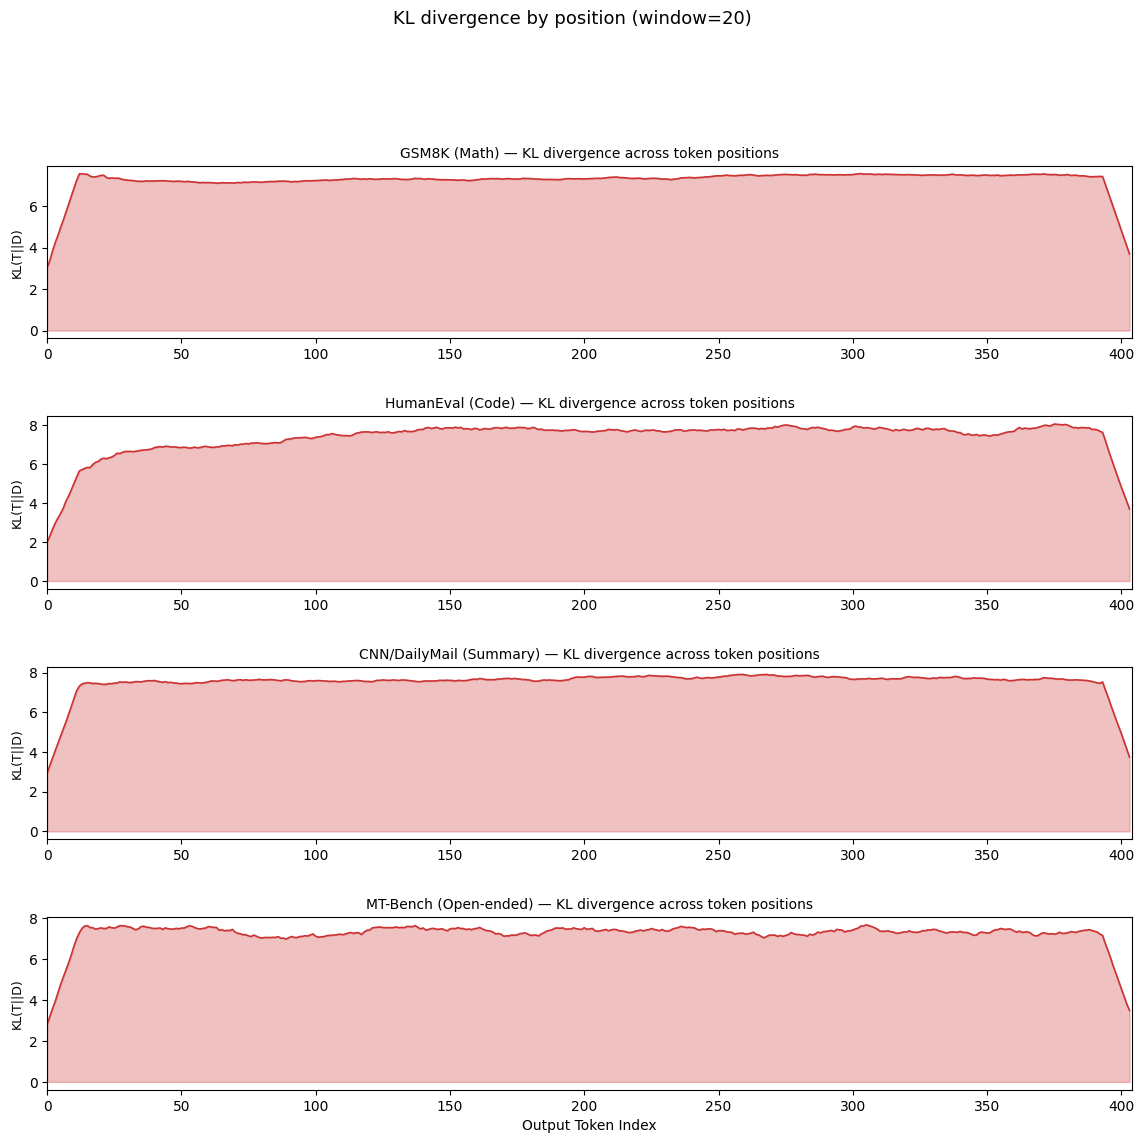

In [46]:
# ── Per-position KL heatmap (sliding window average) ──────────────────────
WINDOW = 20  # tokens

fig, axes = plt.subplots(len(ALL_DATASETS), 1,
                         figsize=(14, 3 * len(ALL_DATASETS)),
                         gridspec_kw={"hspace": 0.45})

for ax, ds_name in zip(axes, ALL_DATASETS):
    # Compute per-position KL for each sequence, then average
    # Use logprob list length (may differ slightly from acceptance mask length)
    max_len = max(len(t) for t in target_logprobs[ds_name])
    kl_matrix = np.full((len(results[ds_name]["acceptance"]), max_len), np.nan)
    
    for i, (t_lps, d_lps) in enumerate(
        zip(target_logprobs[ds_name], draft_logprobs[ds_name])
    ):
        for j, (t_lp, d_lp) in enumerate(zip(t_lps, d_lps)):
            kl_matrix[i, j] = compute_kl_from_logprobs(t_lp, d_lp)
    
    # Sliding window average across position axis
    mean_kl = np.nanmean(kl_matrix, axis=0)
    smoothed = np.convolve(
        np.nan_to_num(mean_kl, nan=0),
        np.ones(WINDOW) / WINDOW, mode="same"
    )
    
    ax.fill_between(range(len(smoothed)), smoothed,
                    alpha=0.3, color="#cc3333")
    ax.plot(smoothed, color="#cc3333", linewidth=1.2)
    ax.set_ylabel("KL(T||D)", fontsize=9)
    ax.set_title(f"{ds_name} — KL divergence across token positions",
                 fontsize=10)
    ax.set_xlim(0, max_len)

axes[-1].set_xlabel("Output Token Index", fontsize=10)
fig.suptitle(
    f"KL divergence by position (window={WINDOW})",
    fontsize=13, y=1.01,
)
plt.savefig("kl_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Experiment 4: Effect of `spec_length` on Acceptance Patterns

How does varying the number of speculative tokens (k=1,2,4,6,8) affect:
- Overall acceptance rate
- Mean acceptance length
- Spatial pattern of easy/hard regions

We use **GSM8K** as the test dataset (representative of structured reasoning).

In [ ]:
SPEC_LENS = [1, 2, 4, 6, 8]
spec_len_results = {}

for k in SPEC_LENS:
    print(f"\n{'='*60}")
    print(f"Running spec_len={k}")
    print(f"{'='*60}")
    
    result = generate_with_tracing(
        prompts=mtbench_prompts,  # 80 prompts — small enough for sweep
        spec_len=k,
        max_new_tokens=MAX_NEW_TOKENS,
    )
    spec_len_results[k] = result
    
    total = sum(len(a) for a in result["acceptance"])
    agreed = sum(sum(a) for a in result["acceptance"])
    print(f"  acceptance={agreed/total:.2%}, "
          f"throughput={result['tok_per_sec']:.1f} tok/s")

In [ ]:
# ── Raster comparison across spec_lens ────────────────────────────────────
# Show first query from MT-Bench across different spec_lens
fig, axes = plt.subplots(len(SPEC_LENS), 1,
                         figsize=(14, 2.5 * len(SPEC_LENS)),
                         gridspec_kw={"hspace": 0.5})

for ax, k in zip(axes, SPEC_LENS):
    acc = spec_len_results[k]["acceptance"]
    labels = [f"Q{i}" for i in range(len(acc))]
    total = sum(len(a) for a in acc)
    agreed = sum(sum(a) for a in acc)
    rate = agreed / total if total else 0
    plot_raster(
        acc, labels,
        title=f"spec_len={k}  (acceptance={rate:.1%})",
        ax=ax,
    )

fig.suptitle(
    "Effect of spec_length on acceptance patterns (MT-Bench)",
    fontsize=13, y=1.01,
)
plt.savefig("spec_len_rasters.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Acceptance rate & throughput vs spec_len ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

rates = []
throughputs = []
mal_values = []  # mean acceptance length

for k in SPEC_LENS:
    acc = spec_len_results[k]["acceptance"]
    total = sum(len(a) for a in acc)
    agreed = sum(sum(a) for a in acc)
    rates.append(agreed / total if total else 0)
    throughputs.append(spec_len_results[k]["tok_per_sec"])
    
    # Compute mean acceptance length from the acceptance mask
    # Each spec round: count consecutive True from start, +1 for bonus
    all_run_lengths = []
    for mask in acc:
        i = 0
        while i < len(mask):
            run = 0
            for j in range(i, min(i + k, len(mask))):
                if mask[j]:
                    run += 1
                else:
                    break
            all_run_lengths.append(run + 1)  # +1 for bonus/resample
            i += run + 1
    mal_values.append(np.mean(all_run_lengths) if all_run_lengths else 1)

# Acceptance rate
ax1.plot(SPEC_LENS, rates, "o-", color=ACCEPT_COLOR,
         linewidth=2, markersize=8, label="Acceptance rate")
ax1.set_xlabel("spec_length (k)", fontsize=11)
ax1.set_ylabel("Token-level acceptance rate", fontsize=11, color=ACCEPT_COLOR)
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)
ax1.set_title("Acceptance rate vs. spec_length", fontsize=12)
for x, y in zip(SPEC_LENS, rates):
    ax1.annotate(f"{y:.1%}", (x, y), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=9)

# Throughput & MAL
color_tp = "#2266aa"
color_mal = "#cc6600"
ax2.plot(SPEC_LENS, throughputs, "s-", color=color_tp,
         linewidth=2, markersize=8, label="Throughput")
ax2.set_xlabel("spec_length (k)", fontsize=11)
ax2.set_ylabel("Throughput (tok/s)", fontsize=11, color=color_tp)
ax2.tick_params(axis="y", labelcolor=color_tp)

ax2b = ax2.twinx()
ax2b.plot(SPEC_LENS, mal_values, "^--", color=color_mal,
          linewidth=2, markersize=8, label="MAL")
ax2b.set_ylabel("Mean Acceptance Length", fontsize=11, color=color_mal)
ax2b.tick_params(axis="y", labelcolor=color_mal)

ax2.set_title("Throughput & MAL vs. spec_length", fontsize=12)
ax2.grid(alpha=0.3)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

plt.tight_layout()
plt.savefig("spec_len_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Per-position acceptance rate at different spec_lens ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

WINDOW = 30
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(SPEC_LENS)))

for k, color in zip(SPEC_LENS, colors):
    acc = spec_len_results[k]["acceptance"]
    max_len = max(len(a) for a in acc)
    
    # Per-position acceptance rate
    pos_rates = np.zeros(max_len)
    pos_counts = np.zeros(max_len)
    for mask in acc:
        for j, a in enumerate(mask):
            pos_rates[j] += int(a)
            pos_counts[j] += 1
    pos_rates = pos_rates / np.maximum(pos_counts, 1)
    
    # Smooth
    smoothed = np.convolve(pos_rates, np.ones(WINDOW)/WINDOW, mode="same")
    ax.plot(smoothed, color=color, linewidth=1.5, label=f"k={k}")

ax.set_xlabel("Output Token Index", fontsize=11)
ax.set_ylabel("Acceptance Rate (smoothed)", fontsize=11)
ax.set_title("Per-position acceptance rate by spec_length (MT-Bench)", fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("acceptance_by_position_spec_len.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary

Collect all results into a summary table.

In [ ]:
print("=" * 80)
print("SUMMARY: Speculative Decoding Acceptance Pattern Analysis")
print(f"Target: {TARGET_MODEL}  |  Draft: {DRAFT_MODEL}  (draft_model method)")
print("=" * 80)

# ── Dataset comparison (spec_len=4) ────────────────────────────────────────
print(f"\n{'Dataset':<30} {'Accept%':>10} {'Entropy_E':>12} "
      f"{'Entropy_H':>12} {'KL_Easy':>10} {'KL_Hard':>10} {'KL_ratio':>10}")
print("-" * 96)
for ds_name in ALL_DATASETS:
    acc = results[ds_name]["acceptance"]
    total = sum(len(a) for a in acc)
    agreed = sum(sum(a) for a in acc)
    rate = agreed / total if total else 0

    e_easy = np.mean(entropy_data[ds_name]["easy"]) if entropy_data[ds_name]["easy"] else 0
    e_hard = np.mean(entropy_data[ds_name]["hard"]) if entropy_data[ds_name]["hard"] else 0
    k_easy = np.mean(kl_data[ds_name]["easy"]) if kl_data[ds_name]["easy"] else 0
    k_hard = np.mean(kl_data[ds_name]["hard"]) if kl_data[ds_name]["hard"] else 0
    k_ratio = k_hard / max(k_easy, 1e-9)

    print(f"{ds_name:<30} {rate:>9.1%} {e_easy:>12.3f} "
          f"{e_hard:>12.3f} {k_easy:>10.4f} {k_hard:>10.4f} {k_ratio:>9.1f}x")

# ── spec_len comparison ────────────────────────────────────────────────────
print(f"\n{'spec_len':>10} {'Accept%':>10} {'tok/s':>10} {'MAL':>10}")
print("-" * 42)
for k, rate, tp, mal in zip(SPEC_LENS, rates, throughputs, mal_values):
    print(f"{k:>10} {rate:>9.1%} {tp:>9.1f} {mal:>9.2f}")

print("\n" + "=" * 80)
print("Key findings:")
print("1. Hard regions have HIGHER entropy and HIGHER KL divergence")
print("2. Acceptance patterns show clear spatial clustering (easy/hard regions)")
print("3. Increasing spec_len reduces per-token acceptance but may")
print("   improve throughput up to a point (diminishing returns)")
print("=" * 80)